# ZQE with synthetic-trained VAE encoder

Instead of the analytical Gaussian-MAP encoder, we train a small neural network
encoder **on draws from the current model** — i.e. supervised posterior approximation:

$$\min_\phi\; \mathbb{E}_{(z,y)\sim p_\theta}[-\log q_\phi(z\mid y)]$$

Because `encoder_factory(g)` is called at the start of each ZQE refinement
round, the encoder is **retrained each round** on the current $\theta$, so it
tracks the decoder automatically (like the parameter-free encoder, but neural).

Rotation is fixed via `lower_tri=True` (same as the sweep).

Comparison:
| # | Encoder | Parameters |
|---|---------|------------|
| 1 | **Gaussian MAP** | none — closed form, always tracks $\theta$ |
| 2 | **Synthetic VAE** | neural net, retrained on $p_\theta$ draws each round |
| 3 | **R `gllvm` (VA)** | — (MLE baseline) |

In [1]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from gllvm.gllvm_module import GLLVM
from gllvm.glms import PoissonGLM
from gllvm.encoder import MapEncoderGaussianLog1p, EncoderPosteriorSupervised
from gllvm.autofit import ZQEAutoFitter, orthogonal_align, procrustes_error
from gllvm.r_gllvm import RGllvm
from gllvm.simulations import make_sparse, simulate
from gllvm import diagnostics as dg

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV)

device: cuda


## Simulation

In [ ]:
NL        = 2
NR        = 20
NS        = 100
WZS       = 0.5
l2        = 0.1 / NS
lower_tri = True

torch.manual_seed(1232345)
g_true = make_sparse(n_latent=NL, poisson=NR, active_latent=NL,
                     wz_scale=WZS, responses_per_latent=NR, lower_tri=lower_tri)
Y_cpu, Z = simulate(g_true, n_samples=NS, device="cpu")
W_true    = g_true.wz.detach()
Y         = Y_cpu.to(DEV)

print(f"p={NR}  q={NL}  n={NS}   y in [{Y.min():.0f}, {Y.max():.0f}]")

p=20  q=2  n=100   y in [0, 41]


## Encoder factory

`SyntheticEncoderFactory` is callable as `factory(g)` — the signature expected by
`ZQEAutoFitter`.  Each call draws fresh synthetic $(z, y)$ pairs from the
**current** model `g` and trains a new `EncoderPosteriorSupervised` on them.
Because the fitter calls `encoder_factory(g)` at the start of each refinement
round, the encoder is always matched to the current $\theta$.

In [3]:
class SyntheticEncoderFactory:
    """Train a posterior encoder on draws from the current model.

    Called as factory(g) by ZQEAutoFitter at the start of each round.
    Uses deterministic MAP (mu only, no reparameterization noise) for z imputation.
    """
    def __init__(self, hidden=64, n_synth=4096, epochs=300, lr=3e-3, verbose=False):
        self.hidden  = hidden
        self.n_synth = n_synth
        self.epochs  = epochs
        self.lr      = lr
        self.verbose = verbose

    def __call__(self, g):
        device = next(g.parameters()).device
        enc = EncoderPosteriorSupervised(
            input_dim=g.p, latent_dim=g.q, hidden=self.hidden
        ).to(device)
        opt = torch.optim.Adam(enc.parameters(), lr=self.lr)

        with torch.no_grad():
            z_synth = torch.randn(self.n_synth, g.q, device=device)
            y_synth = torch.log1p(g.sample(z=z_synth).float())

        bs = 512
        for ep in range(self.epochs):
            idx = torch.randperm(self.n_synth, device=device)[:bs]
            mu, logvar = enc(y_synth[idx])
            logvar = logvar.clamp(-6, 4)
            z_t = z_synth[idx]
            nll  = 0.5 * ((z_t - mu).pow(2) * torch.exp(-logvar) + logvar).mean()
            kl   = 0.5 * (mu.pow(2) + logvar.exp() - 1 - logvar).mean()
            opt.zero_grad(); (nll + kl).backward(); opt.step()

        if self.verbose:
            print(f"  [enc] {self.epochs} epochs  nll={nll.item():.3f}  kl={kl.item():.3f}")

        _enc = enc
        class _Wrapped:
            def sample(self, y):
                mu, logvar = _enc(torch.log1p(y.float()))
                return mu, mu, logvar   # deterministic MAP — no reparameterization noise
        return _Wrapped()

## Shared decoder init and ZQE config

In [4]:
def fresh_decoder():
    g = GLLVM(latent_dim=NL, output_dim=NR, bias=True, lower_tri=lower_tri).to(DEV)
    g.add_glm(PoissonGLM, idx=list(range(NR)), params={"T": torch.log1p}, name="P")
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)
    return g

ZQE_KW = dict(steps_per_round=150, max_rounds=10, tol=0.001,
              refine_lr=0.5, warmup_lr=0.5, ema_decay=0.95,
              l2=l2, verbose=True)

## Fit — Gaussian MAP encoder (reference)

In [5]:
torch.manual_seed(SEED)
g_map = fresh_decoder()
ft_map = ZQEAutoFitter(
    g_map,
    encoder_factory=lambda g: MapEncoderGaussianLog1p(g),
    device=DEV, seed=SEED, **ZQE_KW
).fit(Y)
print(f"\nGaussian MAP   Procrustes={procrustes_error(W_true, ft_map.model.wz):.4f}  "
      f"converged={ft_map.converged_}")

[warm-up] adam lr=0.5 (exit at lr≤0.002)
  ep  100  loss=+0.5058  gnorm=0.5514  lr=5.00e-01
  ep  200  loss=-0.4489  gnorm=0.3990  lr=1.25e-01
  ep  300  loss=-0.7940  gnorm=0.4173  lr=3.12e-02
  ep  400  loss=-0.2696  gnorm=0.3071  lr=7.81e-03
  warm-up done at ep 498 (lr floor reached)
[refine] restart 1/10  change=—  |avg∇W|/|W|=0.0045  lr·|avg∇W|/|W|=2.55e-04  lr0=5.00e-01 lr_eff=5.62e-02  (tol=0.001)
[refine] restart 2/10  change=0.0220  |avg∇W|/|W|=0.0066  lr·|avg∇W|/|W|=1.85e-04  lr0=2.50e-01 lr_eff=2.81e-02  (tol=0.001)
[refine] restart 3/10  change=0.0145  |avg∇W|/|W|=0.0107  lr·|avg∇W|/|W|=1.51e-04  lr0=1.25e-01 lr_eff=1.41e-02  (tol=0.001)
[refine] restart 4/10  change=0.0063  |avg∇W|/|W|=0.0043  lr·|avg∇W|/|W|=3.03e-05  lr0=6.25e-02 lr_eff=7.03e-03  (tol=0.001)
[refine] restart 5/10  change=0.0043  |avg∇W|/|W|=0.0065  lr·|avg∇W|/|W|=2.28e-05  lr0=3.12e-02 lr_eff=3.51e-03  (tol=0.001)
[refine] restart 6/10  change=0.0021  |avg∇W|/|W|=0.0070  lr·|avg∇W|/|W|=1.23e-05  lr0=1.56

## Fit — Synthetic VAE encoder\n\nThe encoder factory is only called at the start of each **refinement** round —\nnot during warm-up. During warm-up θ drifts rapidly, so a neural encoder trained\nat the initial θ would be badly mismatched and the ZQE loss would diverge.\n\nSolution: **warm up with the Gaussian MAP encoder** (which always tracks θ), then\nhand the decoder off to a second `ZQEAutoFitter` with the neural encoder factory\nand `warmup_max_epochs=1` (skip re-warmup, go straight to refinement rounds).\nEach refinement round retrains the encoder on the *current* θ before the ZQE\nsteps, so the encoder stays matched throughout."

In [6]:
import copy

torch.manual_seed(SEED)
g_vae = fresh_decoder()

# Phase 1: warm up with Gaussian MAP encoder — stable from random init.
ft_warmup = ZQEAutoFitter(
    g_vae,
    encoder_factory=lambda g: MapEncoderGaussianLog1p(g),
    device=DEV, seed=SEED, **ZQE_KW
).fit(Y)
print(f"\nAfter warm-up (MAP)  Procrustes={procrustes_error(W_true, g_vae.wz):.4f}")

# Phase 2: refinement with neural encoder retrained each round.
# warmup_max_epochs=1 skips warmup (1 gradient step then exits LR schedule on first check)
# by setting warmup_min_lr = warmup_lr so the floor is hit immediately.
ft_vae = ZQEAutoFitter(
    g_vae,
    encoder_factory=SyntheticEncoderFactory(verbose=True),
    device=DEV, seed=SEED,
    warmup_lr=0.5, warmup_min_lr=0.5,   # floor = start LR → exits warmup after 1 epoch
    warmup_patience=0,
    steps_per_round=150, max_rounds=10, tol=0.001,
    refine_lr=0.3, ema_decay=0.95, l2=l2, verbose=True,
).fit(Y)
print(f"\nSynthetic VAE  Procrustes={procrustes_error(W_true, ft_vae.model.wz):.4f}  "
      f"converged={ft_vae.converged_}")

[warm-up] adam lr=0.5 (exit at lr≤0.002)
  ep  100  loss=+0.5058  gnorm=0.5514  lr=5.00e-01
  ep  200  loss=-0.4489  gnorm=0.3990  lr=1.25e-01
  ep  300  loss=-0.7940  gnorm=0.4173  lr=3.12e-02
  ep  400  loss=-0.2696  gnorm=0.3071  lr=7.81e-03
  warm-up done at ep 498 (lr floor reached)
[refine] restart 1/10  change=—  |avg∇W|/|W|=0.0045  lr·|avg∇W|/|W|=2.55e-04  lr0=5.00e-01 lr_eff=5.62e-02  (tol=0.001)
[refine] restart 2/10  change=0.0220  |avg∇W|/|W|=0.0066  lr·|avg∇W|/|W|=1.85e-04  lr0=2.50e-01 lr_eff=2.81e-02  (tol=0.001)
[refine] restart 3/10  change=0.0145  |avg∇W|/|W|=0.0107  lr·|avg∇W|/|W|=1.51e-04  lr0=1.25e-01 lr_eff=1.41e-02  (tol=0.001)
[refine] restart 4/10  change=0.0063  |avg∇W|/|W|=0.0043  lr·|avg∇W|/|W|=3.03e-05  lr0=6.25e-02 lr_eff=7.03e-03  (tol=0.001)
[refine] restart 5/10  change=0.0043  |avg∇W|/|W|=0.0065  lr·|avg∇W|/|W|=2.28e-05  lr0=3.12e-02 lr_eff=3.51e-03  (tol=0.001)
[refine] restart 6/10  change=0.0021  |avg∇W|/|W|=0.0070  lr·|avg∇W|/|W|=1.23e-05  lr0=1.56

## Fit — R gllvm baseline

## Fit — Online encoder (1 step per 1 step)

At every ZQE step we already draw $(z_q, Y_q) \sim p_\theta$ for the centring
term.  That pair is a fresh supervised signal for the encoder at the **current**
$\theta$ — take exactly one encoder gradient step on it before the decoder step.

No extra sampling.  No per-round retraining.  The encoder's SGD noise is
automatically calibrated to the decoder's SGD noise: both move at the same rate,
so the encoder always approximately tracks $\theta$.  "Jitter" is just the
natural step-size of gradient descent.

In [7]:
def fit_online_encoder(Y, g, hidden=64, enc_lr=3e-3, l2=0.0,
                       n_warmup=500, warmup_lr=0.5,
                       n_refine=1500, refine_lr=0.3, refine_lr_power=0.5,
                       polyak_frac=0.5, verbose=True):
    """ZQE with 1 encoder update per decoder update — fully online, no per-round retraining.

    Uses deterministic MAP (mu only) for z imputation — no reparameterization noise.
    """
    device = next(g.parameters()).device
    n = len(Y)
    y_log = torch.log1p(Y.float())

    enc     = EncoderPosteriorSupervised(g.p, g.q, hidden=hidden).to(device)
    opt_enc = torch.optim.Adam(enc.parameters(), lr=enc_lr)
    opt_dec = torch.optim.Adam(g.parameters(), lr=warmup_lr)
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_dec, factor=0.5, patience=50, min_lr=warmup_lr / 256)

    def _enc_step(z_q, y_q_log):
        mu, logvar = enc(y_q_log)
        logvar = logvar.clamp(-6, 4)
        nll = 0.5 * ((z_q - mu).pow(2) * torch.exp(-logvar) + logvar).mean()
        kl  = 0.5 * (mu.pow(2) + logvar.exp() - 1 - logvar).mean()
        opt_enc.zero_grad(); (nll + kl).backward(); opt_enc.step()

    def _dec_step(opt, y_q_log):
        with torch.no_grad():
            z_enc,   _ = enc(y_log)     # mu only — no reparameterization noise
            z_q_enc, _ = enc(y_q_log)   # mu only
        m1   = g.zq_log(Y,   z=z_enc).mean()
        m2   = g.zq_log(Y_q, z=z_q_enc).mean()
        loss = -(m1 - m2)
        if l2 > 0:
            loss = loss + l2 * g.wz.pow(2).sum()
        opt.zero_grad(); loss.backward(); opt.step()
        if g.wz_mask is not None:
            with torch.no_grad():
                g.wz.data.mul_(g.wz_mask)
        return loss.item()

    if verbose: print(f"[online] warm-up {n_warmup} steps  lr={warmup_lr}")
    for step in range(n_warmup):
        with torch.no_grad():
            z_q  = torch.randn(n, g.q, device=device)
            Y_q  = g.sample(z=z_q)
        y_q_log = torch.log1p(Y_q.float())
        _enc_step(z_q, y_q_log)
        loss = _dec_step(opt_dec, y_q_log)
        sched.step(abs(loss))

    if verbose:
        print(f"  after warm-up  Procrustes={procrustes_error(W_true, g.wz):.4f}")

    if verbose: print(f"[online] refine {n_refine} steps  lr0={refine_lr}")
    opt_r = torch.optim.SGD(g.parameters(), lr=refine_lr)
    running_wz, n_avg = torch.zeros_like(g.wz), 0

    for step in range(n_refine):
        lr_k = refine_lr / (1 + step) ** refine_lr_power
        for pg in opt_r.param_groups: pg["lr"] = lr_k

        with torch.no_grad():
            z_q  = torch.randn(n, g.q, device=device)
            Y_q  = g.sample(z=z_q)
        y_q_log = torch.log1p(Y_q.float())
        _enc_step(z_q, y_q_log)
        _dec_step(opt_r, y_q_log)

        if step >= n_refine * (1 - polyak_frac):
            running_wz += g.wz.detach(); n_avg += 1

    with torch.no_grad():
        g.wz.data.copy_(running_wz / n_avg)
        if g.wz_mask is not None:
            g.wz.data.mul_(g.wz_mask)

    if verbose:
        print(f"  final          Procrustes={procrustes_error(W_true, g.wz):.4f}")
    return g


torch.manual_seed(SEED)
g_online = fresh_decoder()
g_online = fit_online_encoder(Y, g_online, l2=l2, verbose=True)
print(f"\nOnline encoder  Procrustes={procrustes_error(W_true, g_online.wz):.4f}")

[online] warm-up 500 steps  lr=0.5
  after warm-up  Procrustes=0.4344
[online] refine 1500 steps  lr0=0.3
  final          Procrustes=0.4352

Online encoder  Procrustes=0.4352


In [8]:
r = RGllvm(method="VA", family="poisson")
if r.available():
    r_fit = r.fit(Y.cpu().numpy(), num_lv=NL, seed=SEED)
    print(f"R gllvm (VA)   Procrustes={procrustes_error(W_true, r_fit.loadings):.4f}")
else:
    r_fit = None
    print(f"Rscript not found at {r.rscript!r} — skipping")

R gllvm (VA)   Procrustes=0.4639


## Results

Method                  Procrustes    Δ (last)
----------------------------------------------
Gaussian MAP                0.4910      0.0007
Synthetic VAE               0.4466      0.0005
Online encoder              0.4352           —
R gllvm (VA)                0.4639           —


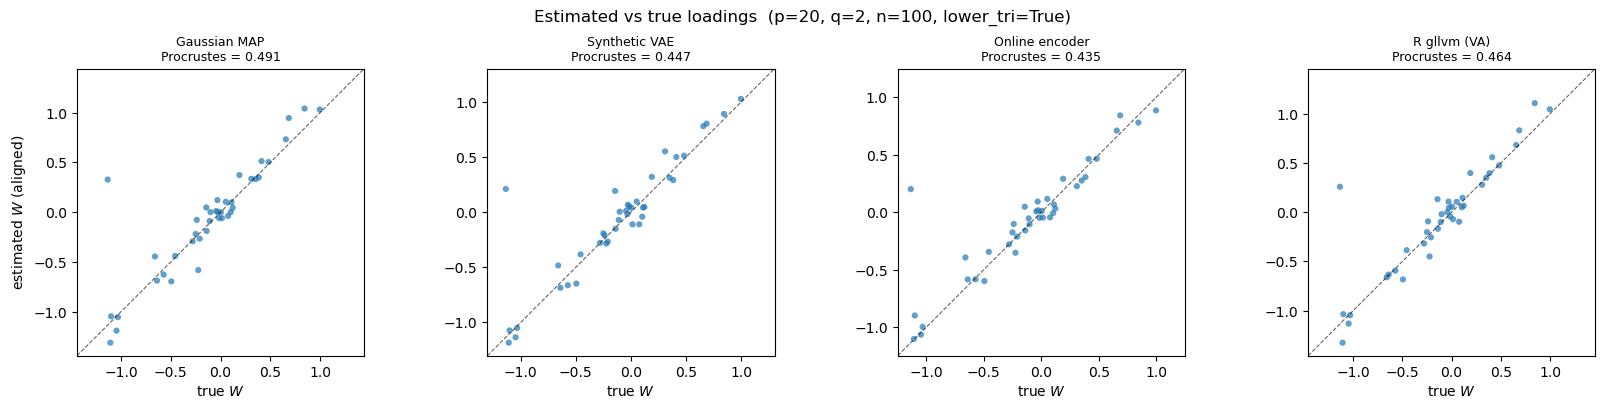

In [9]:
def align(W_hat):
    Wt = W_true.detach().to("cpu", torch.float64)
    We = (W_hat.detach() if isinstance(W_hat, torch.Tensor)
          else torch.as_tensor(np.asarray(W_hat))).to("cpu", torch.float64)
    return (We @ orthogonal_align(Wt, We)).numpy()

methods = [
    ("Gaussian MAP",   ft_map.model.wz,    ft_map.change_),
    ("Synthetic VAE",  ft_vae.model.wz,    ft_vae.change_),
    ("Online encoder", g_online.wz,        float("nan")),
]
if r_fit is not None:
    methods.append(("R gllvm (VA)", r_fit.loadings, float("nan")))

print(f"{'Method':<22}{'Procrustes':>12}{'Δ (last)':>12}")
print("-" * 46)
for name, W_hat, chg in methods:
    chg_s = f"{chg:.4f}" if chg == chg else "—"
    print(f"{name:<22}{procrustes_error(W_true, W_hat):>12.4f}{chg_s:>12}")

Wt_np = W_true.cpu().numpy()
fig, axes = plt.subplots(1, len(methods), figsize=(4.2 * len(methods), 4.0), squeeze=False)
fig.suptitle(f"Estimated vs true loadings  (p={NR}, q={NL}, n={NS}, lower_tri={lower_tri})")
for ax, (name, W_hat, _) in zip(axes[0], methods):
    W_al = align(W_hat)
    ax.scatter(Wt_np.ravel(), W_al.ravel(), s=20, alpha=0.7, edgecolors="none")
    lim = 1.1 * max(np.abs(Wt_np).max(), np.abs(W_al).max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.6)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.set_title(f"{name}\nProcrustes = {procrustes_error(W_true, W_hat):.3f}", fontsize=9)
    ax.set_xlabel("true $W$")
axes[0][0].set_ylabel("estimated $W$ (aligned)")
plt.tight_layout(); plt.show()

## Diagnostics

## Repeat experiment — 10 seeds\n\nTwo parameter-free encoders, same ZQE loss (T=log1p for stability of centring term):\n\n| Encoder | Formula |\n|---|---|\n| **Gaussian MAP** | $z = (W^TW+\\sigma^2 I)^{-1}W^T(\\log_+(y)-b)$ — closed form, log1p proxy |\n| **Poisson MAP** | $z^* = \\arg\\max_z\\{\\sum_j[y_j\\eta_j(z)-e^{\\eta_j(z)}]-\\tfrac{1}{2}\\|z\\|^2\\}$ — Newton, T(y)=y |

## Fit — learned linear encoder (online)\n\nInstead of a neural network, learn a single `(q, p)` matrix `A` such that\n$\\hat z = A\\,\\log_+(y)$.  The optimal `A` is exactly the analytic MAP formula\n$(W^TW + \\sigma^2 I)^{-1}W^T$ — same as `MapEncoderGaussianLog1p` — so this is a\nlossless approximation in the limit.  Updated 1 step per ZQE step using the same\n$(z_q, Y_q)$ draw, with no matrix inversion."

In [10]:
def fit_linear_encoder(Y, g, enc_lr=5e-2, l2=0.0,
                       n_warmup=500, warmup_lr=0.5,
                       n_refine=1500, refine_lr=0.3, refine_lr_power=0.5,
                       polyak_frac=0.5, sigma2=1.0, verbose=True):
    """ZQE with a learnable (q, p) linear encoder  z = A · log1p(y).

    Warmup: analytic A = (W^TW + sigma2·I)^{-1} W^T recomputed each step
            (identical to MapEncoderGaussianLog1p during warmup).
    Refinement: A initialized from post-warmup W, then updated 1 step per ZQE
                step via MSE on the same (z_q, Y_q) batch.

    This "redresses" the Gaussian MAP formula: instead of recomputing (W^TW+σ²I)^{-1}
    analytically every step, A is free to adapt to deviations from the Gaussian proxy.
    Only q×p = 4 parameters (for q=2, p=20).
    """
    device = next(g.parameters()).device
    n = len(Y)
    y_log = torch.log1p(Y.float())

    def _analytic_A():
        W = g.wz.detach()  # (p, q)
        M = torch.linalg.inv(W.T @ W + sigma2 * torch.eye(g.q, device=device))
        return (M @ W.T).detach()  # (q, p)

    A       = torch.nn.Parameter(_analytic_A())
    opt_enc = torch.optim.Adam([A], lr=enc_lr)
    opt_dec = torch.optim.Adam(g.parameters(), lr=warmup_lr)
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_dec, factor=0.5, patience=50, min_lr=warmup_lr / 256)

    def _dec_step(opt, y_q_log, A_enc):
        with torch.no_grad():
            z_enc   = y_log   @ A_enc.T
            z_q_enc = y_q_log @ A_enc.T
        m1   = g.zq_log(Y,   z=z_enc).mean()
        m2   = g.zq_log(Y_q, z=z_q_enc).mean()
        loss = -(m1 - m2)
        if l2 > 0:
            loss = loss + l2 * g.wz.pow(2).sum()
        opt.zero_grad(); loss.backward(); opt.step()
        if g.wz_mask is not None:
            with torch.no_grad(): g.wz.data.mul_(g.wz_mask)
        return loss.item()

    # --- Warmup: analytic A tracks W exactly (no learning) ---
    if verbose: print(f"[linear] warm-up {n_warmup} steps  lr={warmup_lr}")
    for step in range(n_warmup):
        with torch.no_grad():
            z_q = torch.randn(n, g.q, device=device)
            Y_q = g.sample(z=z_q)
        y_q_log = torch.log1p(Y_q.float())
        loss = _dec_step(opt_dec, y_q_log, _analytic_A())
        sched.step(abs(loss))

    if verbose:
        print(f"  after warm-up  Procrustes={procrustes_error(W_true, g.wz):.4f}")

    # --- Refinement: initialize A from post-warmup W, then adapt online ---
    with torch.no_grad():
        A.data.copy_(_analytic_A())

    if verbose: print(f"[linear] refine {n_refine} steps  lr0={refine_lr}")
    opt_r = torch.optim.SGD(g.parameters(), lr=refine_lr)
    running_wz, n_avg = torch.zeros_like(g.wz), 0

    for step in range(n_refine):
        lr_k = refine_lr / (1 + step) ** refine_lr_power
        for pg in opt_r.param_groups: pg["lr"] = lr_k

        with torch.no_grad():
            z_q = torch.randn(n, g.q, device=device)
            Y_q = g.sample(z=z_q)
        y_q_log = torch.log1p(Y_q.float())

        # Encoder step: MSE regression A·log1p(Y_q) → z_q
        z_hat    = y_q_log @ A.T
        enc_loss = (z_q - z_hat).pow(2).mean()
        opt_enc.zero_grad(); enc_loss.backward(); opt_enc.step()

        # Decoder step: use current A (detached — score-function identity)
        _dec_step(opt_r, y_q_log, A.detach())

        if step >= n_refine * (1 - polyak_frac):
            running_wz += g.wz.detach(); n_avg += 1

    with torch.no_grad():
        g.wz.data.copy_(running_wz / n_avg)
        if g.wz_mask is not None:
            g.wz.data.mul_(g.wz_mask)

    if verbose:
        print(f"  final          Procrustes={procrustes_error(W_true, g.wz):.4f}")
    return g


torch.manual_seed(SEED)
g_lin = fresh_decoder()
g_lin = fit_linear_encoder(Y, g_lin, l2=l2, verbose=True)
print(f"\nLinear encoder  Procrustes={procrustes_error(W_true, g_lin.wz):.4f}")

[linear] warm-up 500 steps  lr=0.5
  after warm-up  Procrustes=0.3844
[linear] refine 1500 steps  lr0=0.3
  final          Procrustes=0.3821

Linear encoder  Procrustes=0.3821


In [11]:
from gllvm.encoder import MapEncoderPoissonNewton
import pandas as pd

REPEAT_SEEDS = list(range(10))
records = []

for s in REPEAT_SEEDS:
    torch.manual_seed(1000 + s)
    g_t = make_sparse(n_latent=NL, poisson=NR, active_latent=NL,
                      wz_scale=WZS, responses_per_latent=NR, lower_tri=lower_tri)
    Y_s, _ = simulate(g_t, n_samples=NS, device="cpu")
    Wt_s   = g_t.wz.detach()
    Y_s    = Y_s.to(DEV)

    row = {"seed": s}

    # 1 — Gaussian MAP (log1p proxy)
    torch.manual_seed(s)
    g = fresh_decoder()
    ft = ZQEAutoFitter(g, encoder_factory=lambda g: MapEncoderGaussianLog1p(g),
                       device=DEV, seed=s, **{**ZQE_KW, "verbose": False}).fit(Y_s)
    row["Gaussian MAP"] = float(procrustes_error(Wt_s, ft.model.wz))

    # 2 — Poisson MAP (Newton, T(y)=y — true canonical)
    torch.manual_seed(s)
    g = fresh_decoder()
    ft2 = ZQEAutoFitter(g, encoder_factory=lambda g: MapEncoderPoissonNewton(g),
                        device=DEV, seed=s, **{**ZQE_KW, "verbose": False}).fit(Y_s)
    row["Poisson MAP"] = float(procrustes_error(Wt_s, ft2.model.wz))

    print(f"seed {s:2d}  Gaussian MAP={row['Gaussian MAP']:.3f}  Poisson MAP={row['Poisson MAP']:.3f}")
    records.append(row)

df_rep = pd.DataFrame(records).set_index("seed")
print("\n── mean ──");   print(df_rep.mean().round(4))
print("\n── median ──"); print(df_rep.median().round(4))
print("\n── std ──");    print(df_rep.std().round(4))

seed  0  Gaussian MAP=0.350  Poisson MAP=0.333
seed  1  Gaussian MAP=0.344  Poisson MAP=0.313
seed  2  Gaussian MAP=0.272  Poisson MAP=0.298
seed  3  Gaussian MAP=0.240  Poisson MAP=0.230
seed  4  Gaussian MAP=0.220  Poisson MAP=0.237
seed  5  Gaussian MAP=0.314  Poisson MAP=0.288
seed  6  Gaussian MAP=0.298  Poisson MAP=0.302
seed  7  Gaussian MAP=0.261  Poisson MAP=0.259
seed  8  Gaussian MAP=0.272  Poisson MAP=0.333
seed  9  Gaussian MAP=0.240  Poisson MAP=0.221

── mean ──
Gaussian MAP    0.2812
Poisson MAP     0.2815
dtype: float64

── median ──
Gaussian MAP    0.2723
Poisson MAP     0.2933
dtype: float64

── std ──
Gaussian MAP    0.0444
Poisson MAP     0.0419
dtype: float64


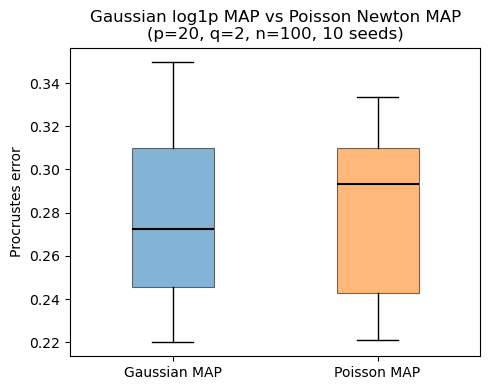

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
cols   = ["Gaussian MAP", "Poisson MAP"]
colors = ["#1f77b4", "#ff7f0e"]
bp = ax.boxplot([df_rep[c].dropna().values for c in cols],
                patch_artist=True, widths=0.4, showfliers=True,
                flierprops=dict(marker="o", markersize=5, alpha=0.6))
for patch, color in zip(bp["boxes"], colors):
    patch.set(facecolor=color, alpha=0.55, edgecolor="k", linewidth=0.8)
for med in bp["medians"]: med.set(color="black", linewidth=1.5)
ax.set_xticks([1, 2]); ax.set_xticklabels(cols)
ax.set_ylabel("Procrustes error")
ax.set_title(f"Gaussian log1p MAP vs Poisson Newton MAP\n(p={NR}, q={NL}, n={NS}, 10 seeds)")
plt.tight_layout(); plt.show()

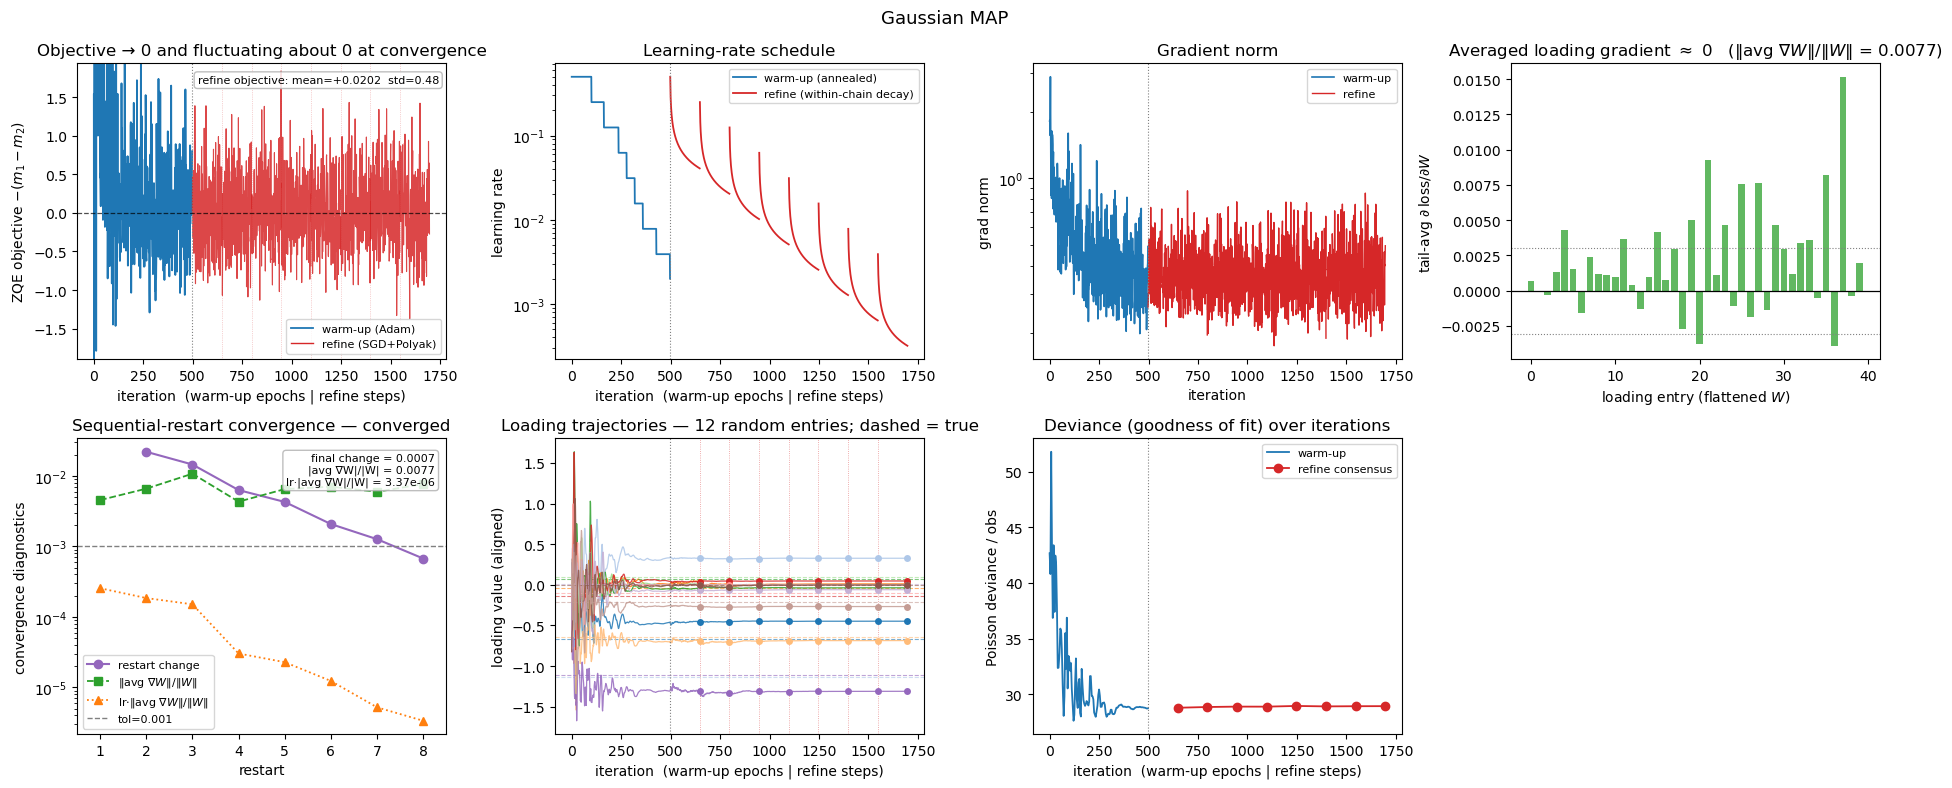

  [enc] 300 epochs  nll=-0.171  kl=0.299


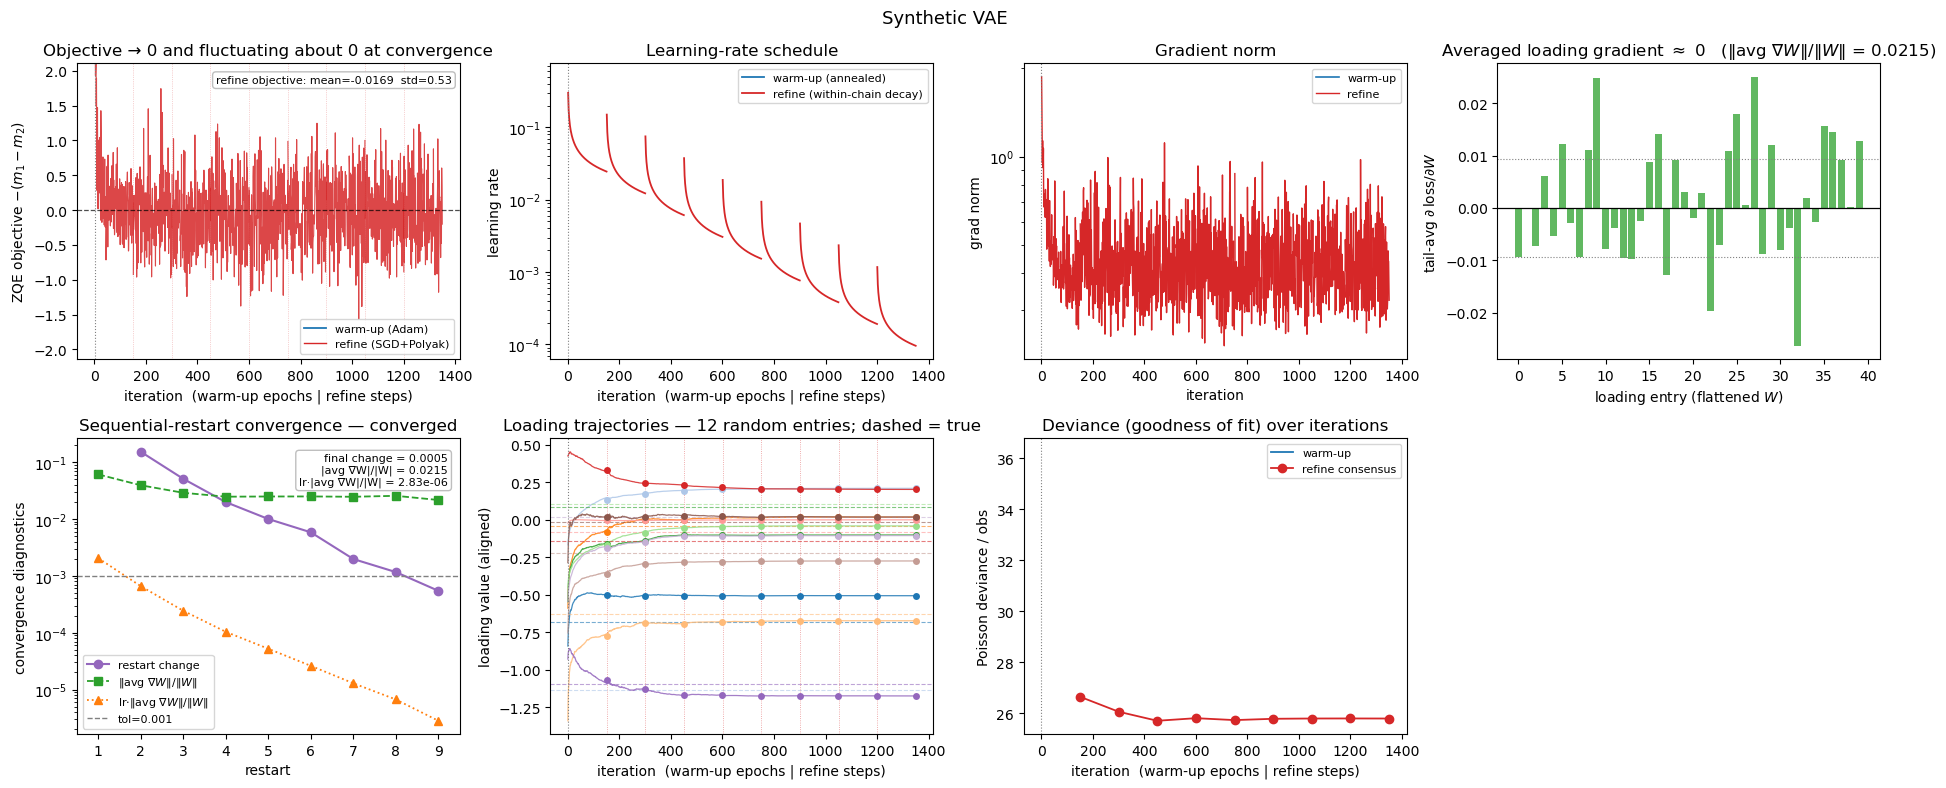

In [13]:
for name, ft in [("Gaussian MAP", ft_map), ("Synthetic VAE", ft_vae)]:
    dg.plot_diagnostics(ft, g_true=g_true, title=name)
    plt.show()